In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from gurobipy import *
from sklearn.cluster import KMeans
import matplotlib.cm as cm
os.chdir("/Users/michael/Desktop/Dissertation")
print(os.getcwd())
np.random.seed(42)

from loadscenariosv2 import *
#from drModel import *
from drModelHighs import * 
from plottingFuncs import * 


/Users/michael/Desktop/Dissertation


## Mathematical Formulation

### Parameters

\begin{align*}
L_{ts} &\quad \text{load at time } t \text{ in scenario } s  \\
\delta_{j,t} &\quad \text{known load change of DR resource } j \text{ at time } t  \\
\delta_{k,t}^{Flex} &\quad \text{known load change of fixed RT DR resource } k \text{ at time } t \\ 
\delta_{k,t}^{Fixed} &\quad \text{known load change of flexible RT DR resource } k \text{ at time } t \\ 
RT^{max} &\quad \text{Max number of RT DR resources that can be called in the period} \\
DA^{max} &\quad \text{Max number of RTDR resources that can be called in the period} \\
\end{align*}

### Variables
\begin{align*}
\Delta L_{jt} &\quad \text{load change by fixed DA DR resource } j \text{ at time } t  \\
\Delta L_{lts}^{Fixed} &\quad \text{load change by fixed RT DR resource } k \text{ at time } t \text{ in scenario } s  \\
\Delta L_{kts}^{Flex} &\quad \text{load change by flexible RT DR resource } k \text{ at time } t \text{ in scenario } s  \\
u_j &\quad \text{binary: 1 if DA Fixed DR resource } j \text{ is activated (DA)} \\
u_{ls}^{Fixed} &\quad \text{binary: 1 if RT Fixed DR resource } l \text{ is activated in scenario } s \text{ (RT)} \\
u_{kts}^{Flex} &\quad \text{binary: 1 if RT Flexible DR resource } k \text{ is activated in scenario } s \text{ (RT)} \\
\pi_s &\quad \text{auxiliary: peak load in scenario } s \\
r_{ts} &\quad \text{auxiliary: absolute ramp between } t-1 \text{ and } t \text{ in scenario } s \\
\end{align*}

### Objective Function

Minimise the Peak and Ramping 

\begin{equation}
\min \quad \alpha\sum_s P_s\, \pi_s \;+\;  (1 - \alpha)\sum_s P_s \sum_{t=2}^{T} r_{ts}
\end{equation}




### Constraints

#### Net Load

\begin{equation}
L_{ts}^{\text{net}} = L_{ts} + \sum_j \Delta L_{jt} + \sum_k \Delta L_{kts}^{Flex} + \sum_l \Delta L_{lts}^{Fixed}  \qquad \forall\, t,\, s
\end{equation}


#### Peak load
\begin{align}
\pi_s &\geq L_{ts}^{\text{net}} \qquad \forall\, t,\, s \\
\end{align}

#### Absolute Ramping Between Periods 
\begin{align}
r_{ts} &\geq L_{ts}^{\text{net}} - L_{t-1,s}^{\text{net}} \qquad \forall\, t \geq 2,\, s \\
r_{ts} &\geq -(L_{ts}^{\text{net}} - L_{t-1,s}^{\text{net}}) \qquad \forall\, t \geq 2,\, s \\
\end{align}


#### DA DR Profile Constraints

\begin{align}
\Delta L_{jt} = \delta_{jt}  u_{j} \qquad \forall\, j,\, t,\ \\
\end{align}


#### Max Number of DA DR resources 
\begin{align}
\sum_j u_{j} & \leq DA^{max}
\end{align}



#### Second Stage RT DR Fixed 

\begin{align}
\Delta L_{lts}^{Fixed} &= \delta^{Fixed}_{lt}  u_{ls}^{Fixed} \qquad \forall\, l,\, t,\, s \\
\end{align}

#### Second Stage DR flexible 

Use a convolution constraint to shift the response profile $\delta_{jk}^{Flex}$ according to each activation time. 

\begin{align}
\Delta L_{k,t,s}^{Flex} &= \sum_{\substack{t' \,:\, 0 \le t - t' \le H_k-1}}^t \delta_{k,t-t'}^{Flex}\, u_{k,t',s}^{Flex} && \forall k \in  K,\, t \in T , s \in S \\[4pt]
\end{align}


Limit how often a DR event can be called.

\begin{align}
\sum_{t \in T} u_{k,t,s}^{Flex} &\le 1
&& \forall k \in K, s \in S  \\[4pt]
\end{align}

Ensure an event cannot be called if it over runs the period length 
\begin{align}
u_{k,t,s}^{Flex} &= 0 \quad \text{if } t + H_k - 1 > T-1 
&& \forall k \in K,\, t \in T, s \in S  \\[4pt]
\end{align}

#### Proportion of Fixed and Flexible RT DR Resources
\begin{align}
\sum_j \sum_t u^{Flex}_{kts} & \leq (1-p)RT^{max}  \qquad\forall \ s\\
\sum_l u^{Fixed}_{ls} & \leq pRT^{max} \qquad \forall s
\end{align}


#### Domain Constriants
\begin{align}
\pi_s &\geq 0 \qquad \forall\, s \\
u_j &\in \{0, 1\} \qquad \forall\, j \\
r_{ts} &\geq 0 \qquad \forall\, t,\, s \\
u_{kts}^{Flex} &\in \{0, 1\} \qquad \forall\, k,\, s, \\
u_{ls}^{Fixed} &\in \{0, 1\} \qquad \forall\, l,\, s
\end{align}


## Parameters 

In [2]:
# Scenario Generation Params 

n_scenarios = 5
std_load = 0.03


# Model Params
alpha = 0.5 # Trade off between Minimising Peak and Minimising ramping  1 is all peak 
beta = 0.5 # Proportion of Fixed DR resources  vs Flexible, 1 is all Fixed
max_rt_DR = 3 # Total number of RT DR resources 
max_da_DR = 5 # Total number of DA DR resources 



## DR Profiles

### DA Fixed Profile

In [3]:
scheduled_profiles = np.array([

    [0,0,0,0,0,0,0,0,0,0,2,4,6,8,6,2,-10,-10,-6,-2,0,0,0,0],

    [0,0,0,0,0,0,0,0,0,2,4,6,8,8,6,4,-12,-15,-12,-5,0,0,0,0],

    [0,0,0,0,0,0,0,0,0,0,5,8,10,10,8,5,-18,-18,-12,-6,0,0,0,0],

    [0,0,0,0,0,0,0,0,2,4,6,8,8,6,4,2,-10,-12,-10,-6,-2,0,0,0],

    [0,0,0,0,0,0,0,0,3,5,7,9,9,7,5,3,-15,-15,-12,-8,-3,0,0,0],

])

### RT Fixed Profiles

In [4]:
rt_fixed_profiles = np.array([

    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-10,-10,8,6,4,2,0,0],

    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-8,-8,10,4,2,0,0,0,0],

    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-15,-15,-10,10,8,5,2,0,0],

    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-20,-20,-20,8,8,8,4,4],

    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-12,-10,-8,6,5,3,2,0],

    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-25,-25,0,12,10,3,0,0,0],

])

### RT Flexible Start Profiles

In [5]:
delta_raw = [
    np.array([-15, -15, +15, +15]),
    np.array([-10, -10, +20]),
    np.array([-20, -20, +30, +10]),
    np.array([+5, +5, -20, +5, +5]),
]

H = np.array([len(row) for row in delta_raw]) 

# Pad with 0s so are all equal length 
delta_flexible = np.zeros((len(H), H.max()))
for k in range(len(H)):
    delta_flexible[k, :H[k]] = delta_raw[k]

## Call Model

/Users/michael/Desktop/Dissertation/loadscenariosv2.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  histLoads['TimeStamp'] = pd.to_datetime(histLoads['TimeStamp'])


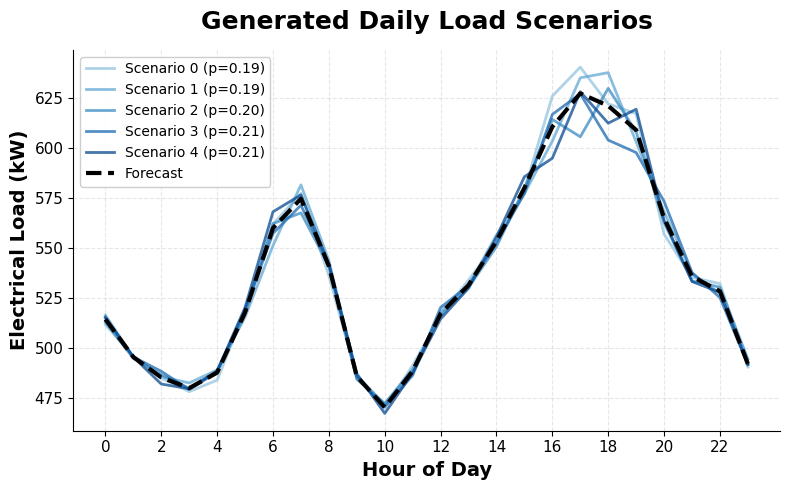

In [6]:
p,load_scenarios =  loadscenarios(n_scenarios, std_load)

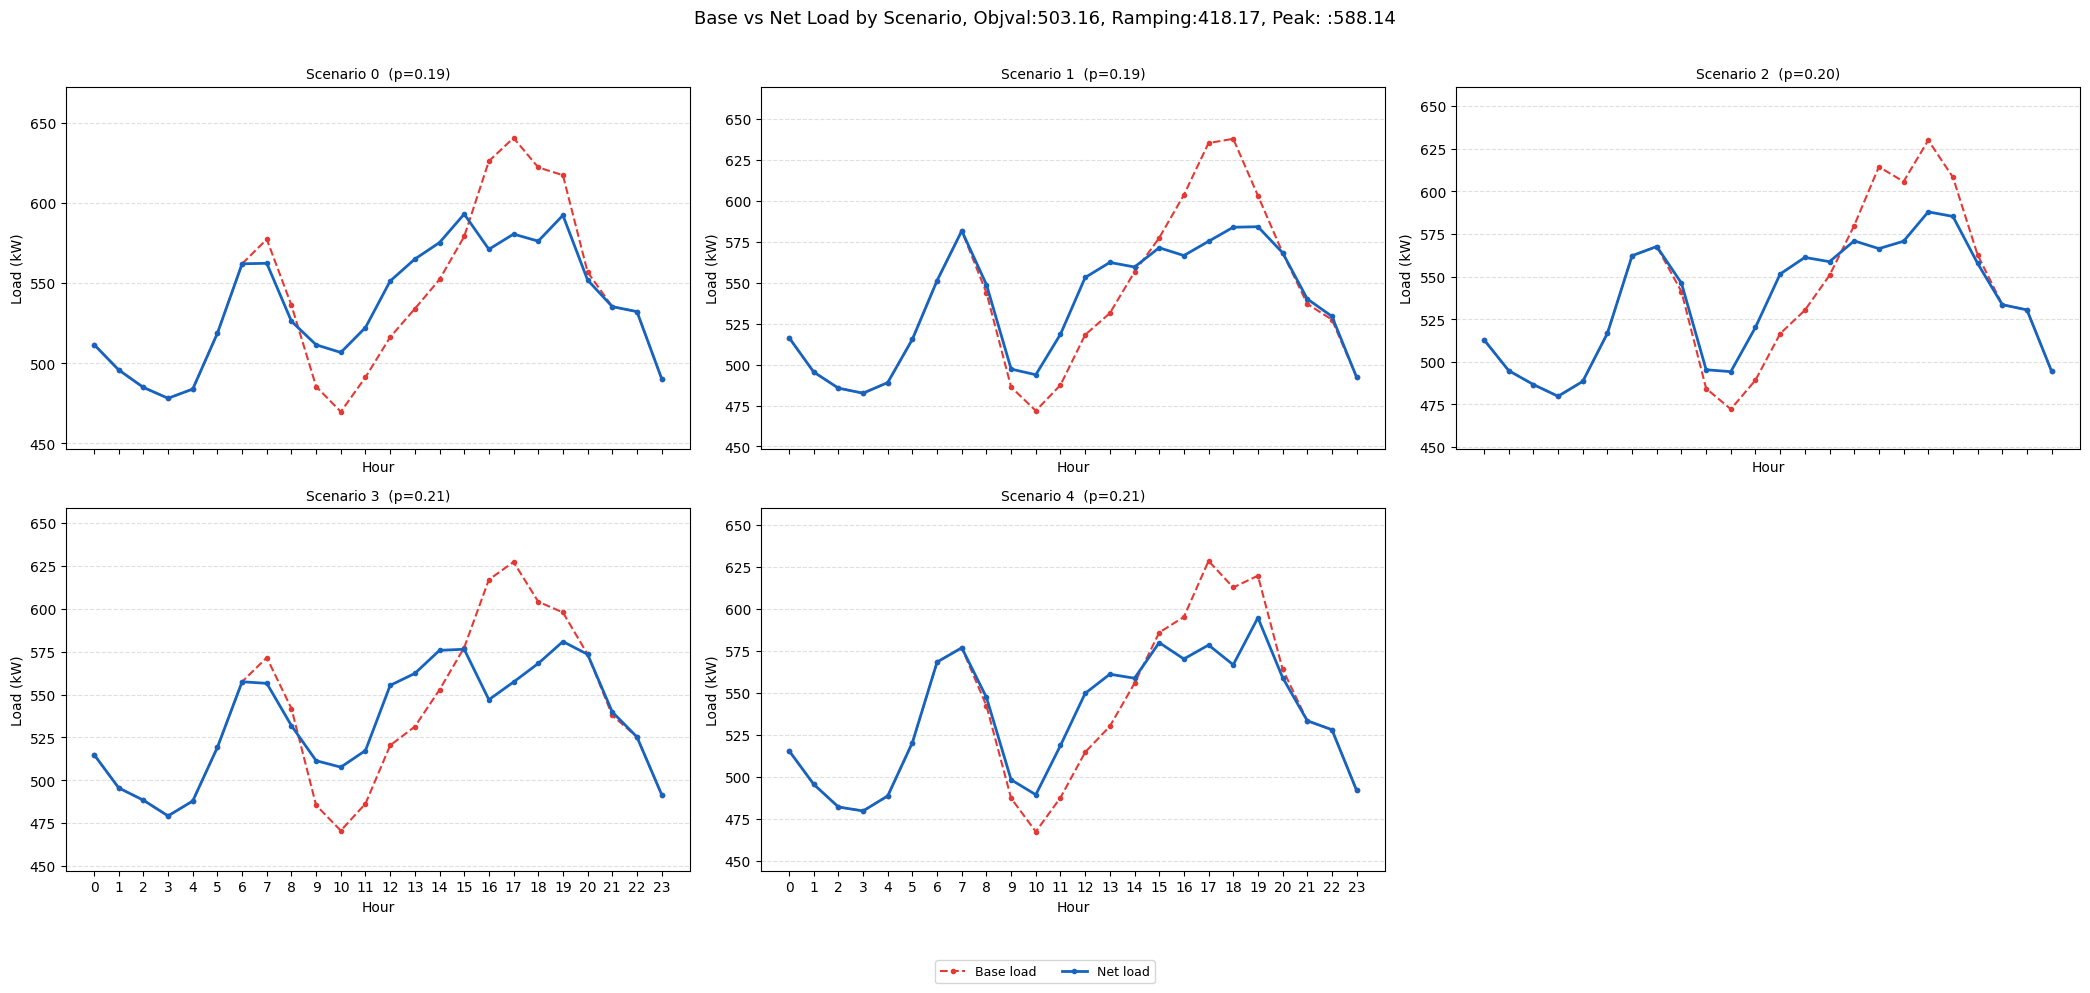

In [7]:
L_net_vals, delta_L_vals, delta_L_Flex_vals, delta_L_Fixed_vals, drModel, objval, r_vals, pi_vals= DRModel(alpha, beta, max_rt_DR, max_da_DR, H, scheduled_profiles, delta_flexible, rt_fixed_profiles, n_scenarios, p, load_scenarios)
plotLoadprofiles(L_net_vals, delta_L_vals, delta_L_Flex_vals, delta_L_Fixed_vals, p, load_scenarios, n_scenarios, objval, r_vals, pi_vals)

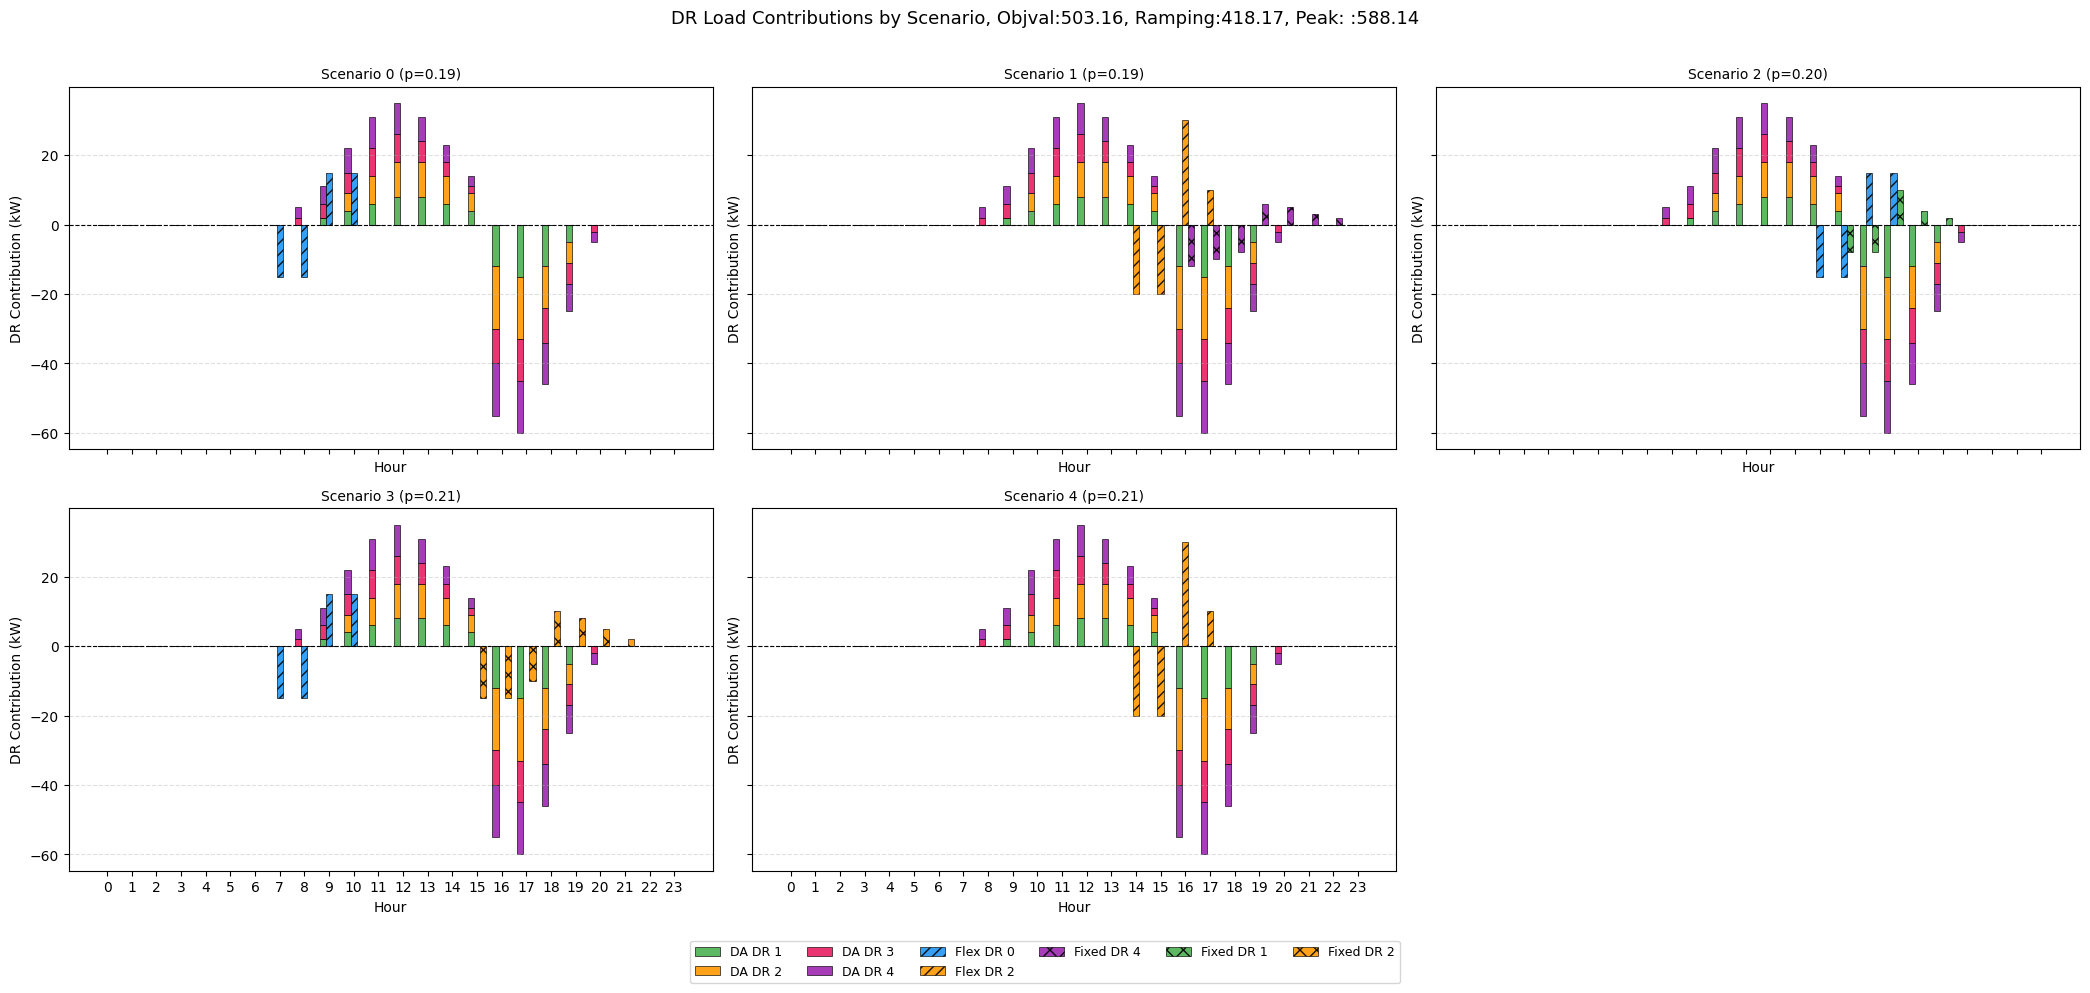

In [8]:
plotDRUsage(L_net_vals, delta_L_vals, delta_L_Flex_vals, delta_L_Fixed_vals, p, objval, r_vals,pi_vals)

## Sensitivity Analysis 

In [9]:
betas = np.arange(0, 1, 0.1)
alphas = np.arange(0, 1, 0.1)
objVals = np.zeros((len(alphas), len(betas)))

peakVals = np.zeros((len(alphas), len(betas)))
rampVals =  np.zeros((len(alphas), len(betas)))

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        L_net_vals, delta_L_vals, delta_L_Flex_vals, delta_L_Fixed_vals, drModel, objval, r_vals,pi_vals= DRModel(alpha, beta, max_rt_DR,max_da_DR,  H, scheduled_profiles, delta_flexible, rt_fixed_profiles, n_scenarios, p, load_scenarios)
        objVals[i, j] = objval

        S = sorted(set(s for s, t in L_net_vals.keys()))
        T = sorted(set(t for s, t in L_net_vals.keys()))
        
        rampVals[i, j] = sum(p[s] * sum(r_vals[s, t] for t in T) for s in S)
        peakVals[i, j] = sum(p[s] * pi_vals[s] for s in S)     


### Objective Val Weighted combination of Ramping and Peak Value

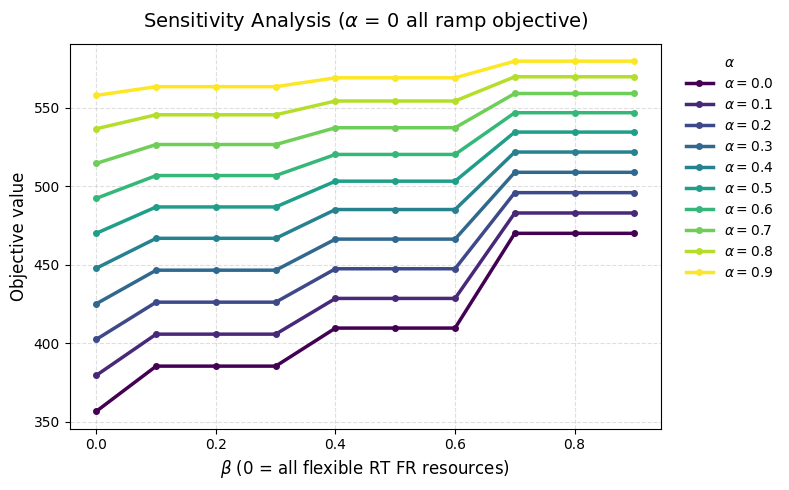

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = cm.viridis(np.linspace(0, 1, len(alphas)))

for alpha, obj, color in zip(alphas, objVals, colors):
    ax.plot(
        betas,
        obj,
        lw=2.5,
        color=color,
        marker='o',
        markersize=4,
        label=fr'$\alpha={alpha:.1f}$'
    )

ax.set_title(r'Sensitivity Analysis ($\alpha$ = 0 all ramp objective)',  fontsize=14, pad=12)
ax.set_xlabel(r'$\beta$ (0 = all flexible RT FR resources)', fontsize=12)
ax.set_ylabel('Objective value', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    title=r'$\alpha$',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

### Peak Load Unweighted

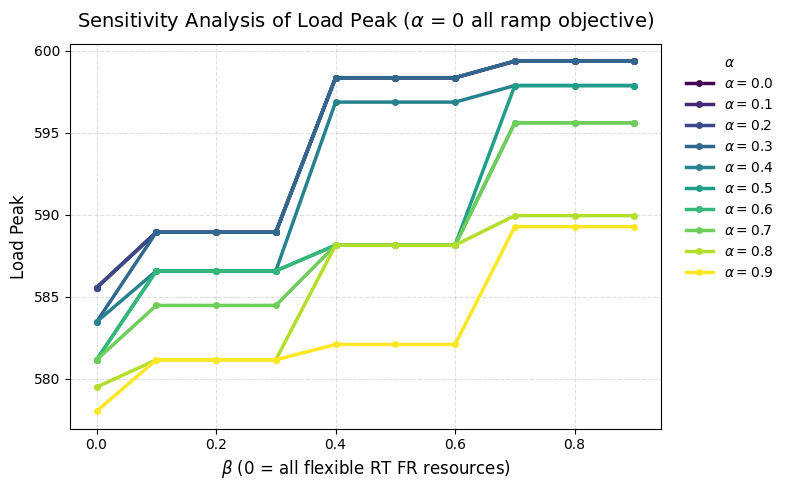

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = cm.viridis(np.linspace(0, 1, len(alphas)))

for alpha, obj, color in zip(alphas, peakVals, colors):
    ax.plot(
        betas,
        obj,
        lw=2.5,
        color=color,
        marker='o',
        markersize=4,
        label=fr'$\alpha={alpha:.1f}$'
    )

ax.set_title(r'Sensitivity Analysis of Load Peak ($\alpha$ = 0 all ramp objective)',  fontsize=14, pad=12)
ax.set_xlabel(r'$\beta$ (0 = all flexible RT FR resources)', fontsize=12)
ax.set_ylabel('Load Peak', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    title=r'$\alpha$',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

### Ramping Unweighted 

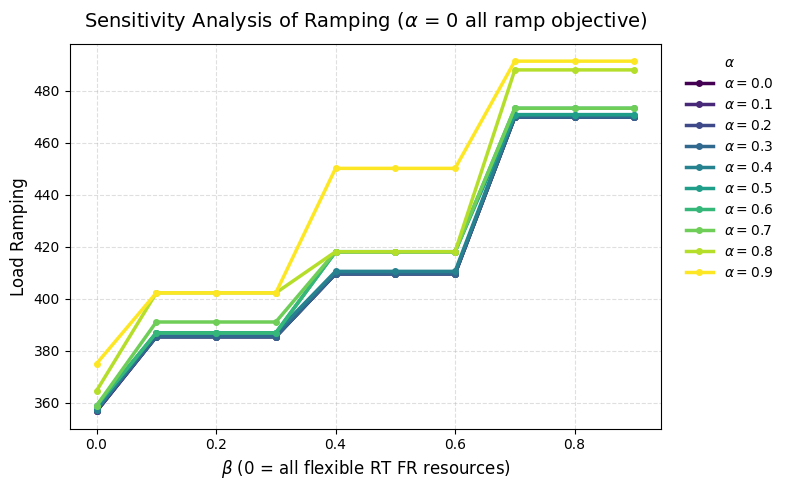

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = cm.viridis(np.linspace(0, 1, len(alphas)))

for alpha, obj, color in zip(alphas, rampVals, colors):
    ax.plot(
        betas,
        obj,
        lw=2.5,
        color=color,
        marker='o',
        markersize=4,
        label=fr'$\alpha={alpha:.1f}$'
    )

ax.set_title(r'Sensitivity Analysis of Ramping ($\alpha$ = 0 all ramp objective)',  fontsize=14, pad=12)
ax.set_xlabel(r'$\beta$ (0 = all flexible RT FR resources)', fontsize=12)
ax.set_ylabel('Load Ramping', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(
    title=r'$\alpha$',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()